In [1]:
# =============================================================================
# UNSW-NB15 DATASET: COMPLETE SECURITY ANALYTICS
# =============================================================================
# Models: Decision Tree (ML), AdaBoost (ML), and Deep Learning (Keras)
# 1. Dataset Concatenation & Preparation
# 2. 8 Strategic & Simple EDA Visualizations
# 3. Manual Random Oversampling for Class Balance
# 4. Professional Evaluation & Performance Rank Table
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import warnings

# --- Global Configurations ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# -----------------------------------------------------------------------------
# STEP 1: LOAD & CONCATENATE DATASETS
# -----------------------------------------------------------------------------
try:
    train_df = pd.read_csv('UNSW_NB15_training-set.csv')
    test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

    # Merge both files into one single dataset
    df = pd.concat([train_df, test_df], ignore_index=True)
    print(f"✓ Datasets Merged. Total Records: {df.shape[0]}, Total Features: {df.shape[1]}")

    # Drop irrelevant identifier
    if 'id' in df.columns:
        df.drop('id', axis=1, inplace=True)

except Exception as e:
    print(f"Error during loading: {e}")

✓ Datasets Merged. Total Records: 257673, Total Features: 45


In [3]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,2,0,0,0,1,2,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,2,0,0,0,1,2,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,3,0,0,0,1,3,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,1,3,0,0,0,2,3,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,1,3,0,0,0,2,3,0,Normal,0


In [4]:
df.tail()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
257668,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,13,24,0,0,0,24,24,0,Generic,1
257669,0.505762,tcp,-,FIN,10,8,620,354,33.612649,254,...,1,2,0,0,0,1,1,0,Shellcode,1
257670,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,13,0,0,0,3,12,0,Generic,1
257671,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,14,30,0,0,0,30,30,0,Generic,1
257672,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,16,30,0,0,0,30,30,0,Generic,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  object 
 2   service            257673 non-null  object 
 3   state              257673 non-null  object 
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  di

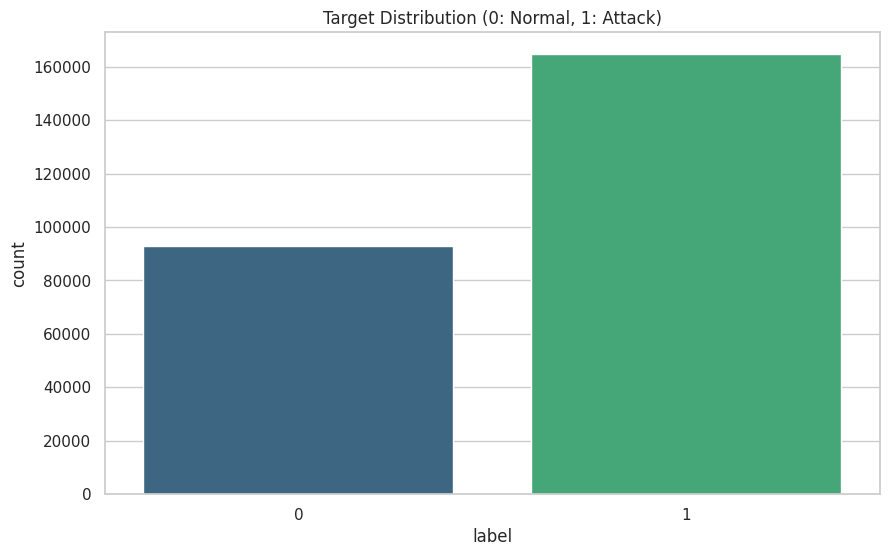

In [6]:
# 1. Target Class Count (Normal vs. Attack)
plt.figure()
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Target Distribution (0: Normal, 1: Attack)')
plt.show()

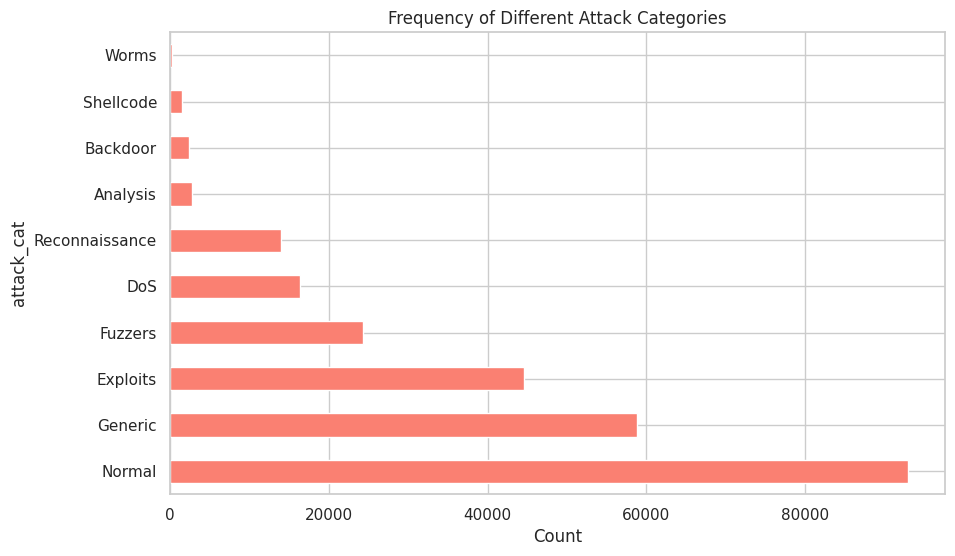

In [7]:
# 2. Attack Category Frequency
plt.figure()
df['attack_cat'].value_counts().plot(kind='barh', color='salmon')
plt.title('Frequency of Different Attack Categories')
plt.xlabel('Count')
plt.show()

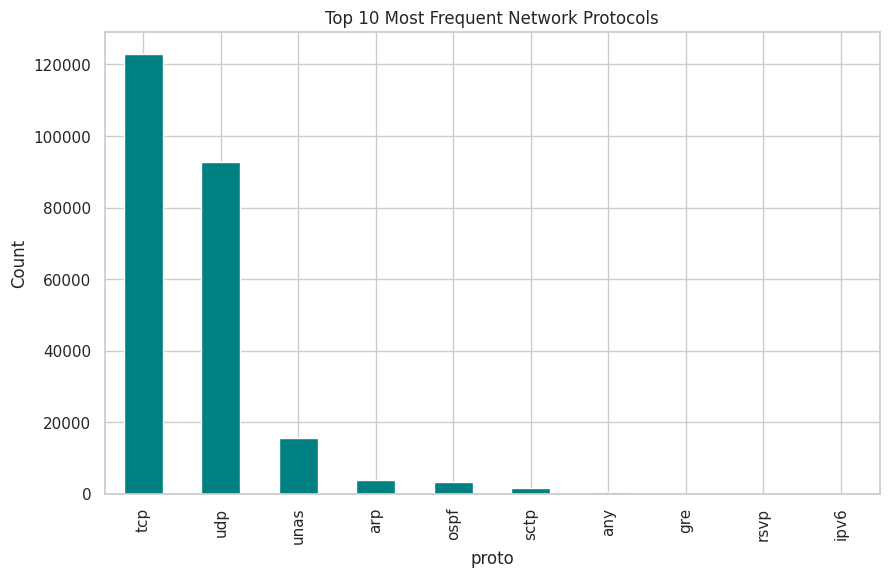

In [8]:
plt.figure()
df['proto'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Most Frequent Network Protocols')
plt.ylabel('Count')
plt.show()

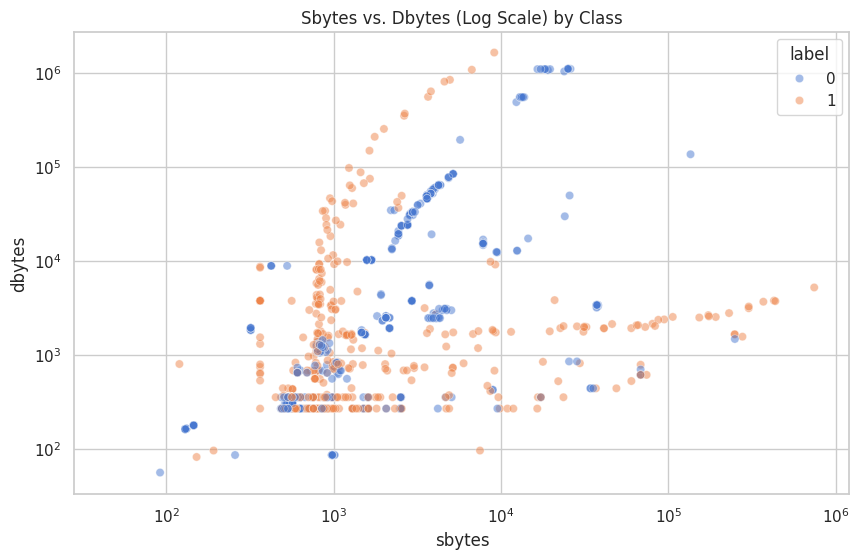

In [10]:
plt.figure()
# Sample for clarity
sns.scatterplot(x='sbytes', y='dbytes', hue='label', data=df.sample(2000), alpha=0.5)
plt.yscale('log')
plt.xscale('log')
plt.title('Sbytes vs. Dbytes (Log Scale) by Class')
plt.show()

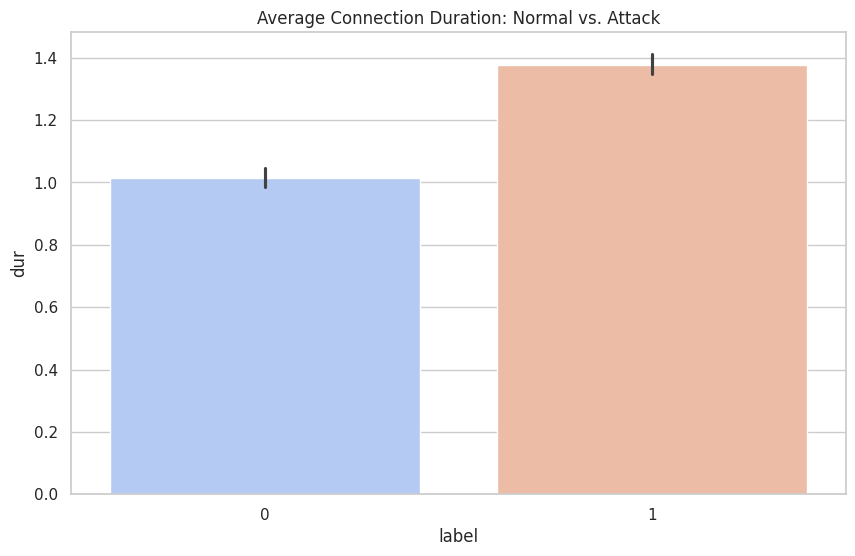

In [11]:
plt.figure()
sns.barplot(x='label', y='dur', data=df, palette='coolwarm')
plt.title('Average Connection Duration: Normal vs. Attack')
plt.show()

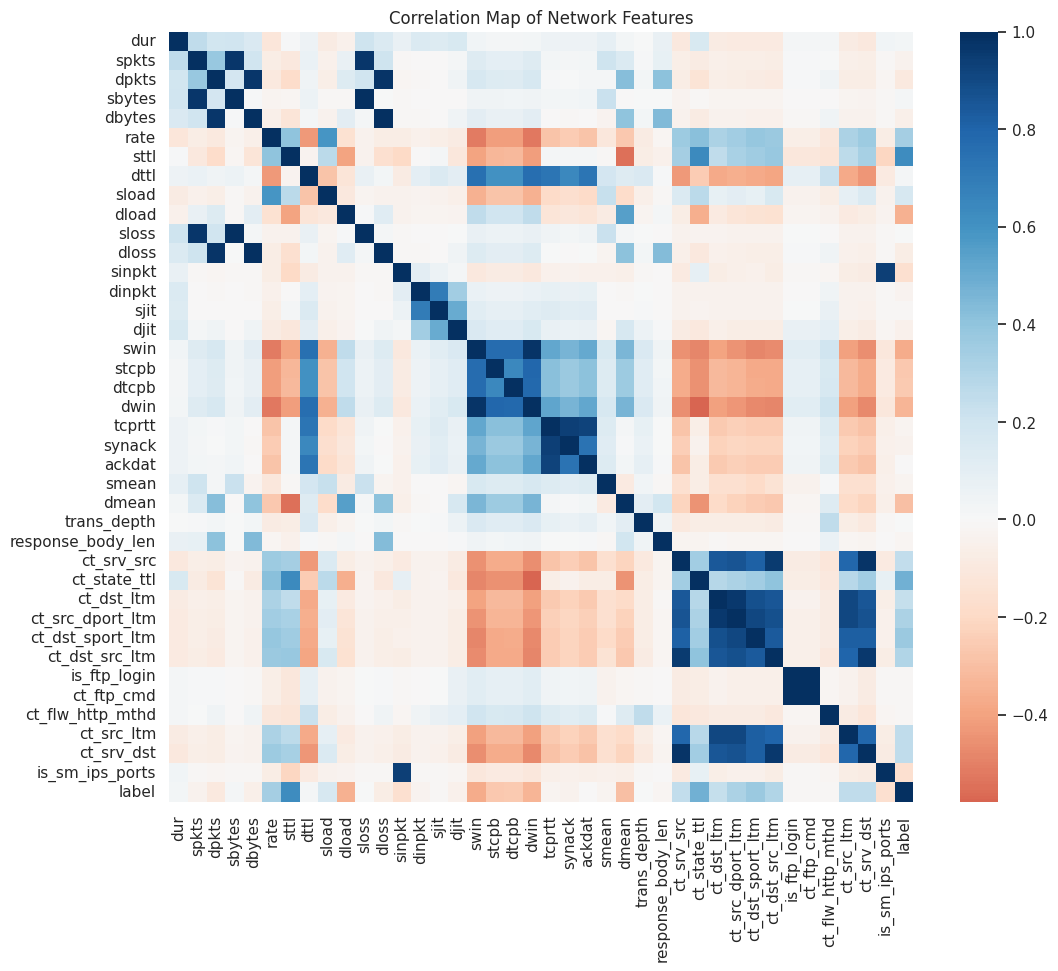

In [12]:
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='RdBu', center=0)
plt.title('Correlation Map of Network Features')
plt.show()

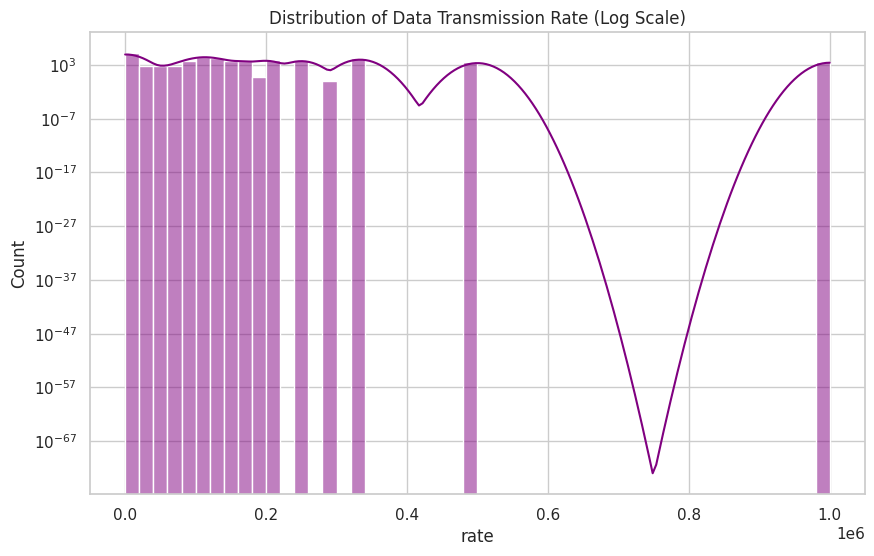

In [13]:
plt.figure()
sns.histplot(df['rate'], bins=50, kde=True, color='purple')
plt.yscale('log')
plt.title('Distribution of Data Transmission Rate (Log Scale)')
plt.show()

In [14]:
# -----------------------------------------------------------------------------
# STEP 3: PRE-PROCESSING & MANUAL OVERSAMPLING
# -----------------------------------------------------------------------------
# Work with a representative sample for training speed in this environment
df_sub = df.sample(n=min(len(df), 60000), random_state=42)

# Encoding Categorical Features
le = LabelEncoder()
cat_cols = ['proto', 'service', 'state']
for col in cat_cols:
    df_sub[col] = le.fit_transform(df_sub[col].astype(str))

# Define Features and Target
X = df_sub.drop(['label', 'attack_cat'], axis=1)
y = df_sub['label']

# Initial Split
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- MANUAL RANDOM OVERSAMPLING ---
train_combined = pd.concat([X_train_raw, y_train_raw], axis=1)
df_maj = train_combined[train_combined.label == 1]
df_min = train_combined[train_combined.label == 0]

# Upsample the Normal traffic (minority in this specific sample)
df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_balanced = pd.concat([df_maj, df_min_upsampled])

X_train = train_balanced.drop('label', axis=1)
y_train = train_balanced['label']

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# -----------------------------------------------------------------------------
# STEP 4: MODEL TRAINING (ML & DEEP LEARNING)
# -----------------------------------------------------------------------------
results = []

# --- Model 1: Decision Tree (ML) ---
print("\nTraining Decision Tree Model...")
dt = DecisionTreeClassifier(max_depth=12, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)

results.append({
    "Algorithm": "Decision Tree (ML)",
    "Accuracy": round(accuracy_score(y_test, dt_preds), 4),
    "Precision": round(precision_score(y_test, dt_preds), 4),
    "Recall": round(recall_score(y_test, dt_preds), 4),
    "F1-Score": round(f1_score(y_test, dt_preds), 4)
})

# --- Model 2: AdaBoost (ML) ---
print("Training AdaBoost Classifier...")
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)
ada_preds = ada.predict(X_test_scaled)

results.append({
    "Algorithm": "AdaBoost (ML)",
    "Accuracy": round(accuracy_score(y_test, ada_preds), 4),
    "Precision": round(precision_score(y_test, ada_preds), 4),
    "Recall": round(recall_score(y_test, ada_preds), 4),
    "F1-Score": round(f1_score(y_test, ada_preds), 4)
})

# --- Model 3: Deep Neural Network (DL) ---
print("Training Deep Learning Neural Network...")
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dl_model.fit(X_train_scaled, y_train, epochs=15, batch_size=64, verbose=0)

# Evaluate DL Model
dl_probs = dl_model.predict(X_test_scaled)
dl_preds = (dl_probs > 0.5).astype(int).flatten()

results.append({
    "Algorithm": "Deep Learning (ANN)",
    "Accuracy": round(accuracy_score(y_test, dl_preds), 4),
    "Precision": round(precision_score(y_test, dl_preds), 4),
    "Recall": round(recall_score(y_test, dl_preds), 4),
    "F1-Score": round(f1_score(y_test, dl_preds), 4)
})


Training Decision Tree Model...
Training AdaBoost Classifier...
Training Deep Learning Neural Network...
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [16]:
# -----------------------------------------------------------------------------
# STEP 5: FINAL PERFORMANCE RANK TABLE
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*70)
print("ALGORITHM PERFORMANCE RANK TABLE (UNSW-NB15)")
print("="*70)
print(rank_table)


ALGORITHM PERFORMANCE RANK TABLE (UNSW-NB15)
                Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                            
1      Decision Tree (ML)    0.9271     0.9672  0.9169    0.9414
2     Deep Learning (ANN)    0.9223     0.9721  0.9042    0.9369
3           AdaBoost (ML)    0.9132     0.9522  0.9097    0.9304


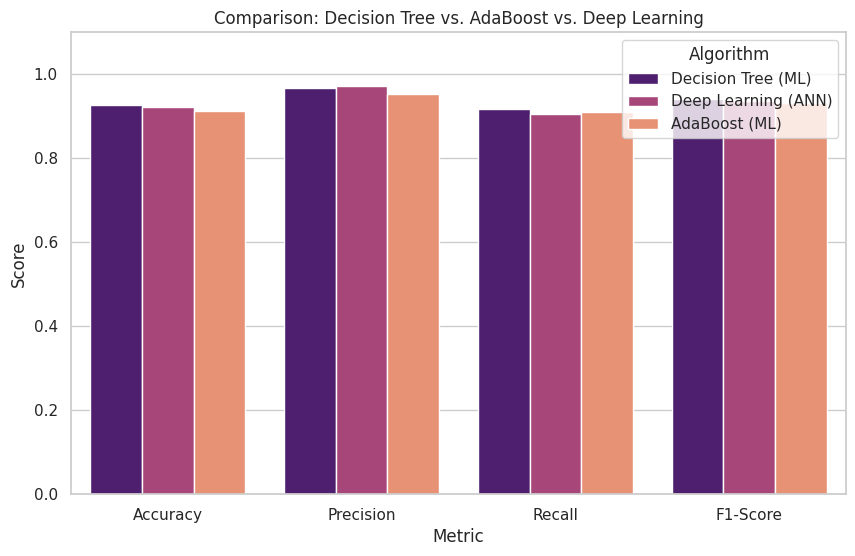

In [17]:
# Visual Comparison
plt.figure()
melted = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=melted, palette='magma')
plt.title('Comparison: Decision Tree vs. AdaBoost vs. Deep Learning')
plt.ylim(0, 1.1)
plt.show()